In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

left = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'patients_left_lme_DTI.tsv'), sep = '\t')
left['Week'] = left['week'].str.extract(r'(\d+)') # get numeric values
left['region_bilat'] = left['regionname'].str[:3]
left['LesionSide'] = 'left '

left.loc[(left.LesionSide == 'left ') & (left.regionname.str[-1] == 'L'), 'side'] = 'ipsilesional'
left.loc[(left.LesionSide == 'left ') & (left.regionname.str[-1] == 'R'), 'side'] = 'contralesional'

left['Week'] = left['Week'].astype(int)
left = left.sort_values('Week')



right = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'patients_right_lme_DTI.tsv'), sep = '\t')
right['Week'] = right['week'].str.extract(r'(\d+)') # get numeric values
right['region_bilat'] = right['regionname'].str[:3]
right['LesionSide'] = 'right'

right.loc[(right.LesionSide == 'right') & (right.regionname.str[-1] == 'L'), 'side'] = 'contralesional'
right.loc[(right.LesionSide == 'right') & (right.regionname.str[-1] == 'R'), 'side'] = 'ipsilesional'

right['Week'] = right['Week'].astype(int)
right = right.sort_values('Week')


# observed values
obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI.tsv'), sep = '\t')

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
metric = 'FaMap'
obs = obs[obs.metric == metric]
obs = obs[~obs.subj_id.isin(controls)]

obs['region_bilat'] = obs['Object'].str[:3]
obs.loc[(obs.LesionSide == 'left ') * (obs.Object.str[-1] == 'L'), 'side'] = 'ipsilesional'
obs.loc[(obs.LesionSide == 'left ') * (obs.Object.str[-1] == 'R'), 'side'] = 'contralesional'
obs.loc[(obs.LesionSide == 'right') * (obs.Object.str[-1] == 'L'), 'side'] = 'contralesional'
obs.loc[(obs.LesionSide == 'right') * (obs.Object.str[-1] == 'R'), 'side'] = 'ipsilesional'


/localscratch/tmp/ipykernel_69019/1749711020.py:34: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI.tsv'), sep = '\t')


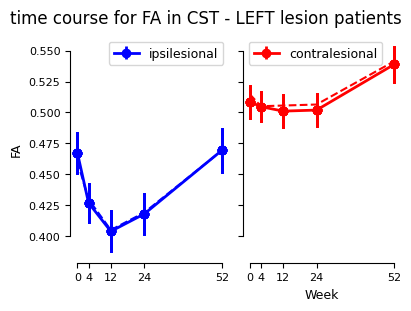

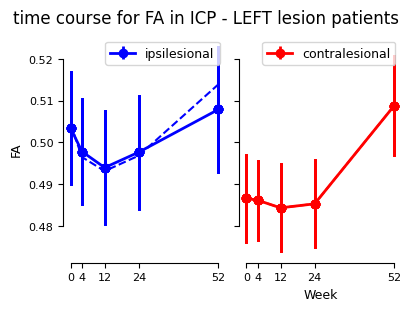

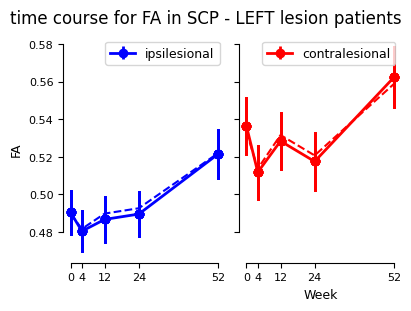

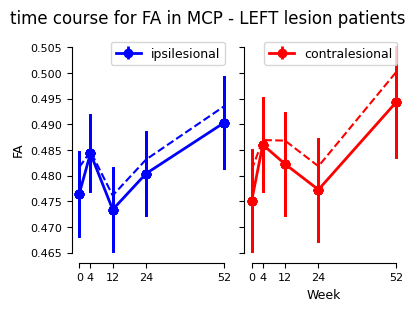

In [2]:
colours_left = ['blue', 'red']

for r, region in enumerate(left.region_bilat.unique()):
    left_lme = left[(left.region_bilat == region)].sort_values('Week')
    left_obs = obs[(obs.region_bilat == region) & (obs.LesionSide == 'left ')].sort_values('week_num')

    fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

    for i, side in enumerate(left.side.unique()):
        ax = axs[i]

        left_lme_side = left_lme[left_lme.side == side].sort_values("Week")
        left_obs_side = left_obs[left_obs.side == side].sort_values("week_num")
        left_obs_side = left_obs_side.groupby(['week_num']).agg({'Mean': 'mean'}).reset_index()

        ax.errorbar(x = left_lme_side['Week'], y = left_lme_side['beta'], yerr = left_lme_side['se'], fmt = '-o', linewidth = 2, color = colours_left[i], label = side)
        ax.plot(left_obs_side['week_num'], left_obs_side['Mean'], linestyle = '--', color = colours_left[i])

    for ax in axs:
        ax.legend()
        ax.set_xticks(gl.weeks)
        axs[0].set_ylabel("FA")
        axs[1].set_xlabel("Week")


    plt.suptitle(f"time course for FA in {region} - LEFT lesion patients")
    sns.despine(trim = True)
    plt.show()


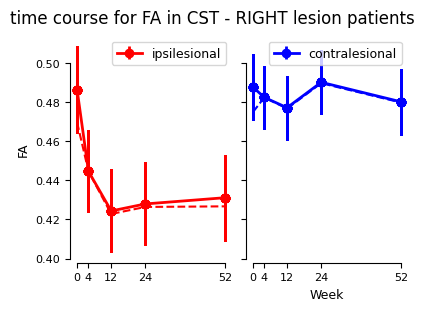

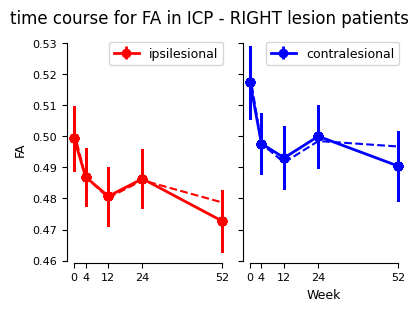

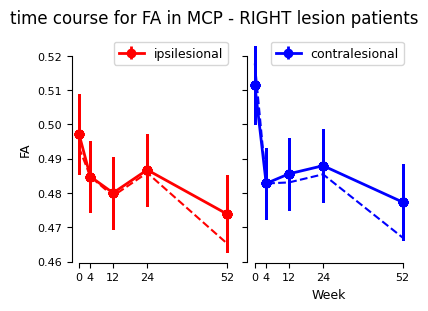

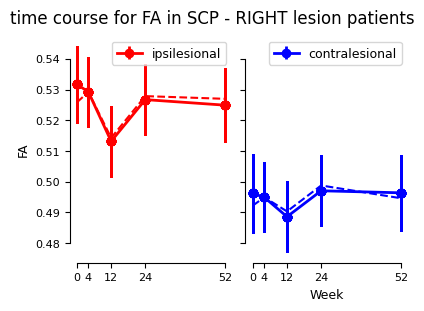

In [3]:
colours_right = ['red', 'blue']
for r, region in enumerate(right.region_bilat.unique()):
    right_lme = right[(right.region_bilat == region)].sort_values('Week')
    right_obs = obs[(obs.region_bilat == region) & (obs.LesionSide == 'right')].sort_values('week_num')

    fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

    for i, side in enumerate(right.side.unique()):
        ax = axs[i]

        right_lme_side = right_lme[right_lme.side == side].sort_values("Week")
        right_obs_side = right_obs[right_obs.side == side].sort_values("week_num")
        right_obs_side = right_obs_side.groupby(['week_num']).agg({'Mean': 'mean'}).reset_index()

        ax.errorbar(x = right_lme_side['Week'], y = right_lme_side['beta'], yerr = right_lme_side['se'], fmt = '-o', linewidth = 2, color = colours_right[i], label = side)
        ax.plot(right_obs_side['week_num'], right_obs_side['Mean'], linestyle = '--', color = colours_right[i])

    for ax in axs:
        ax.legend()
        ax.set_xticks(gl.weeks)
        axs[0].set_ylabel("FA")
        axs[1].set_xlabel("Week")


    plt.suptitle(f"time course for FA in {region} - RIGHT lesion patients")
    sns.despine(trim = True)
    plt.show()